In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Percentile Computation

In [2]:
array = [66, 67, 67, 68, 68, 68, 68, 69, 69, 69, 69, 70, 70, 71, 71, 72, 73, 73, 73]

print("First Quartile: ", np.percentile(array, 25)) # p = 25%
print("Second Quartile: ", np.percentile(array, 50))# p = 50%
print("Third Quartile: ", np.percentile(array, 75)) # p = 75%

First Quartile:  68.0
Second Quartile:  69.0
Third Quartile:  71.0


In [3]:
array = [1, 2, 3, 4, 5]

print("First Quartile: ", np.percentile(array, 25)) # p = 25%
print("Second Quartile: ", np.percentile(array, 50))# p = 50%
print("Third Quartile: ", np.percentile(array, 75)) # p = 75%

First Quartile:  2.0
Second Quartile:  3.0
Third Quartile:  4.0


In [4]:
array = [1, 2, 3, 4, 5, 6]

print("First Quartile: ", np.percentile(array, 25)) # p = 25%
print("Second Quartile: ", np.percentile(array, 50))# p = 50%
print("Third Quartile: ", np.percentile(array, 75)) # p = 75%

First Quartile:  2.25
Second Quartile:  3.5
Third Quartile:  4.75


### Fun Case Study: Dravid vs. Sehwag

In [6]:
sehwag = pd.read_csv("sehwag.csv")
dravid = pd.read_csv("dravid.csv")

In [7]:
dravid.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Unnamed: 9,Opposition,Ground,Start Date,Unnamed: 13
0,3,-,4,0,0,75.00,4,caught,1,NaN,v Sri Lanka,Singapore,3 Apr 1996,ODI # 1089
1,4,-,7,0,0,57.14,4,run out,1,NaN,v Pakistan,Singapore,5 Apr 1996,ODI # 1091
2,3,-,5,0,0,60.00,5,caught,2,NaN,v Pakistan,Sharjah,12 Apr 1996,ODI # 1094
3,11,28,21,0,0,52.38,8,caught,2,NaN,v South Africa,Sharjah,14 Apr 1996,ODI # 1097
4,22,21,15,3,0,146.66,6,not out,1,NaN,v England,Manchester,26 May 1996,ODI # 1104


In [38]:
## Calculate Dravid's stats
p_25 = np.percentile(dravid["Runs"], 25)
p_50 = np.percentile(dravid["Runs"], 50)
p_75 = np.percentile(dravid["Runs"], 75)

print("First Quartile: ", p_25) # p = 25%
print("Second Quartile: ", p_50)# p = 50%
print("Third Quartile: ", p_75) # p = 75%

print("IQR: ", p_75 - p_25)

left_whis  = max(p_25 - 1.5 * (p_75 - p_25), 0)
right_whis = p_75 + 1.5 * (p_75 - p_25)

print("Left: ", left_whis)
print("Right: ", right_whis)

num_outliers = len(dravid[dravid["Runs"] > right_whis])
print("Dravid's outliers: ", num_outliers)

print("Dravid's std: ", dravid["Runs"].std())

First Quartile:  10.0
Second Quartile:  26.0
Third Quartile:  54.0
IQR:  44.0
Left:  0
Right:  120.0
Dravid's outliers:  3
Dravid's std:  29.681822462366085


<AxesSubplot:>

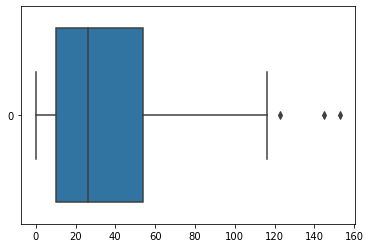

In [18]:
sns.boxplot(data=dravid["Runs"], orient="h")

In [10]:
sehwag.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Unnamed: 9,Opposition,Ground,Start Date,Unnamed: 13
0,1,5,2,0,0,50.00,7,lbw,1,NaN,v Pakistan,Mohali,1 Apr 1999,ODI # 1427
1,19,18,24,0,1,79.16,6,caught,1,NaN,v Zimbabwe,Rajkot,14 Dec 2000,ODI # 1660
2,58,62,54,8,0,107.40,6,bowled,1,NaN,v Australia,Bengaluru,25 Mar 2001,ODI # 1696
3,2,7,7,0,0,28.57,6,caught,2,NaN,v Zimbabwe,Bulawayo,27 Jun 2001,ODI # 1730
4,11,19,16,1,0,68.75,6,not out,2,NaN,v West Indies,Bulawayo,30 Jun 2001,ODI # 1731


In [37]:
## Calculate Sehwag's stats
p_25 = np.percentile(sehwag["Runs"], 25)
p_50 = np.percentile(sehwag["Runs"], 50)
p_75 = np.percentile(sehwag["Runs"], 75)

print("First Quartile: ", p_25) # p = 25%
print("Second Quartile: ", p_50)# p = 50%
print("Third Quartile: ", p_75) # p = 75%

print("IQR: ", p_75 - p_25)

left_whis  = max(p_25 - 1.5 * (p_75 - p_25), 0)
right_whis = p_75 + 1.5 * (p_75 - p_25)

print("Left: ", left_whis)
print("Right: ", right_whis)

num_outliers = len(sehwag[sehwag["Runs"] > right_whis])
print("Sehwag's outliers: ", num_outliers)

print("Sehwag's std: ", sehwag["Runs"].std())

First Quartile:  8.0
Second Quartile:  23.0
Third Quartile:  46.0
IQR:  38.0
Left:  0
Right:  103.0
Sehwag's outliers:  14
Sehwag's std:  34.80941899427947


<AxesSubplot:>

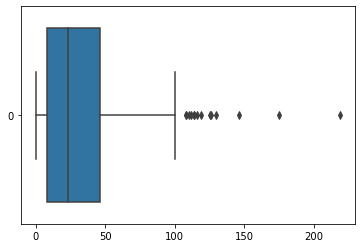

In [19]:
sns.boxplot(data=sehwag["Runs"], orient="h")

### CDF Computation

In [21]:
df_hw = pd.read_csv("weight-height.csv")
df_hw

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [23]:
df_height = df_hw["Height"]
df_height

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [25]:
min_height = df_height.min()
max_height = df_height.max()
x_values = np.linspace(min_height, max_height, len(df_height))
y_values = []

In [28]:
for x in x_values:
    people_with_height_shorter_than_x = df_height[df_height <= x]
    num_people_shorter_than_x = len(people_with_height_shorter_than_x)
    frac_people_shorter_than_x = num_people_shorter_than_x / len(df_height)
    y_values.append(frac_people_shorter_than_x)

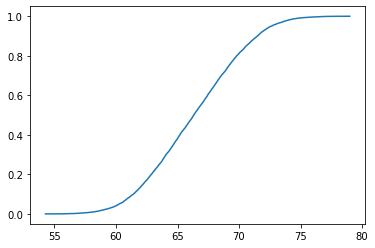

In [32]:
plt.plot(x_values, y_values)